# ANÁLISE DE DADOS DE PREÇOS DE CASAS NOS ESTADOS UNIDOS

## Objetivo do Estudo

Este projeto tem como objetivo proporcionar uma experiência prática nas diferentes etapas do processo de análise de dados e da construção de modelos de aprendizado de máquina, desde a exploração dos dados até a avaliação dos resultados obtidos.

A análise busca desenvolver e aplicar os seguintes conceitos:

- Análise exploratória de dados
- Feature engineering
- Aprendizagem supervisionada
- Aprendizagem não supervisionada
- Métricas de avaliação e comparação


In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from category_encoders import TargetEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.options.display.float_format = '{:.2f}'.format


In [41]:
df_original = pd.read_csv('train.csv')

## Conjunto de dados macro 

In [42]:
print(df_original.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL        65.00     8450   Pave   NaN      Reg   
1   2          20       RL        80.00     9600   Pave   NaN      Reg   
2   3          60       RL        68.00    11250   Pave   NaN      IR1   
3   4          70       RL        60.00     9550   Pave   NaN      IR1   
4   5          60       RL        84.00    14260   Pave   NaN      IR1   

  LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
0         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
1         Lvl    AllPub       FR2       Gtl      Veenker      Feedr   
2         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
3         Lvl    AllPub    Corner       Gtl      Crawfor       Norm   
4         Lvl    AllPub       FR2       Gtl      NoRidge       Norm   

  Condition2 BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  \
0       Norm     1Fam     2Story            7          

In [43]:
df_original.shape

(1460, 81)

In [44]:
print(df_original.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Verificação de dados nulos

In [6]:
print(df_original.isnull().sum())

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

## Valores únicos de cada variável 

In [7]:
valores_unicos = []
for i in df_original.columns[0:80].tolist():
    print(i, ':', len(df_original[i].astype(str).value_counts()))
    valores_unicos.append(len(df_original[i].astype(str).value_counts()))

Id : 1460
MSSubClass : 15
MSZoning : 5
LotFrontage : 111
LotArea : 1073
Street : 2
Alley : 3
LotShape : 4
LandContour : 4
Utilities : 2
LotConfig : 5
LandSlope : 3
Neighborhood : 25
Condition1 : 9
Condition2 : 8
BldgType : 5
HouseStyle : 8
OverallQual : 10
OverallCond : 9
YearBuilt : 112
YearRemodAdd : 61
RoofStyle : 6
RoofMatl : 8
Exterior1st : 15
Exterior2nd : 16
MasVnrType : 4
MasVnrArea : 328
ExterQual : 4
ExterCond : 5
Foundation : 6
BsmtQual : 5
BsmtCond : 5
BsmtExposure : 5
BsmtFinType1 : 7
BsmtFinSF1 : 637
BsmtFinType2 : 7
BsmtFinSF2 : 144
BsmtUnfSF : 780
TotalBsmtSF : 721
Heating : 6
HeatingQC : 5
CentralAir : 2
Electrical : 6
1stFlrSF : 753
2ndFlrSF : 417
LowQualFinSF : 24
GrLivArea : 861
BsmtFullBath : 4
BsmtHalfBath : 3
FullBath : 4
HalfBath : 3
BedroomAbvGr : 8
KitchenAbvGr : 4
KitchenQual : 4
TotRmsAbvGrd : 12
Functional : 7
Fireplaces : 4
FireplaceQu : 6
GarageType : 7
GarageYrBlt : 98
GarageFinish : 4
GarageCars : 5
GarageArea : 441
GarageQual : 6
GarageCond : 6
PavedDr

## Correlação do Preço de Venda com variáveis qualitativas

In [8]:
print(df_original['SalePrice'].describe())

count     1460.00
mean    180921.20
std      79442.50
min      34900.00
25%     129975.00
50%     163000.00
75%     214000.00
max     755000.00
Name: SalePrice, dtype: float64


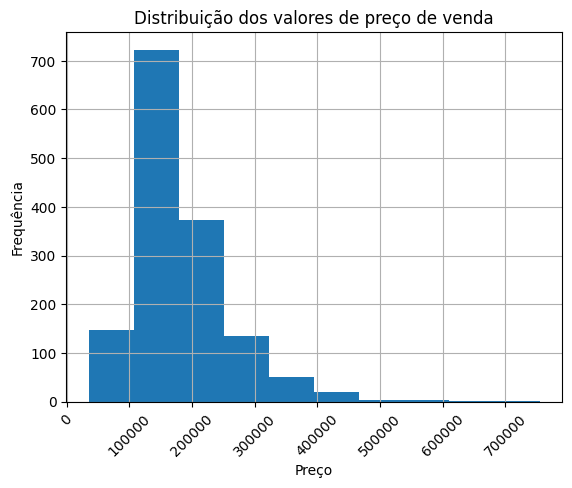

In [9]:
df_original['SalePrice'].hist()
plt.title('Distribuição dos valores de preço de venda')
plt.xlabel('Preço')
plt.ylabel('Frequência')


plt.xticks(rotation=45)
plt.show()

Relação Preço (SalePrice) x bairro (Neighborhood)

In [10]:
df_original.groupby('Neighborhood')['SalePrice'].mean()

Neighborhood
Blmngtn   194870.88
Blueste   137500.00
BrDale    104493.75
BrkSide   124834.05
ClearCr   212565.43
CollgCr   197965.77
Crawfor   210624.73
Edwards   128219.70
Gilbert   192854.51
IDOTRR    100123.78
MeadowV    98576.47
Mitchel   156270.12
NAmes     145847.08
NPkVill   142694.44
NWAmes    189050.07
NoRidge   335295.32
NridgHt   316270.62
OldTown   128225.30
SWISU     142591.36
Sawyer    136793.14
SawyerW   186555.80
Somerst   225379.84
StoneBr   310499.00
Timber    242247.45
Veenker   238772.73
Name: SalePrice, dtype: float64

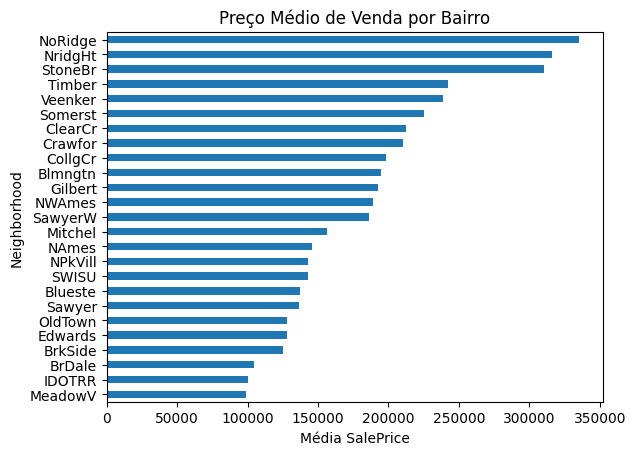

In [11]:
(
    df_original.groupby('Neighborhood')['SalePrice']
    .mean()
    .sort_values()
    .plot(kind='barh')
)

plt.ylabel('Neighborhood')
plt.xlabel('Média SalePrice')
plt.title('Preço Médio de Venda por Bairro')

plt.show()

Relação Preço (SalePrice) x Qualidade do material do exterior (ExterQual)

In [12]:
df_original.groupby('ExterQual')['SalePrice'].mean()

ExterQual
Ex   367360.96
Fa    87985.21
Gd   231633.51
TA   144341.31
Name: SalePrice, dtype: float64

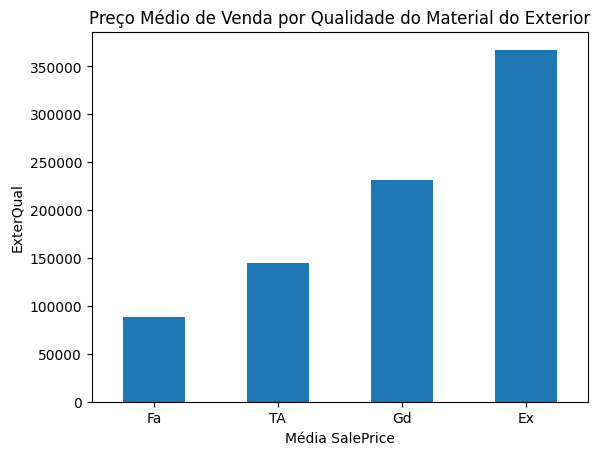

In [13]:
(
    df_original.groupby('ExterQual')['SalePrice']
    .mean()
    .sort_values()
    .plot(kind='bar')
)

plt.ylabel('ExterQual')
plt.xlabel('Média SalePrice')
plt.title('Preço Médio de Venda por Qualidade do Material do Exterior')


plt.xticks(rotation=0)
plt.show()

Relação Preço (SalePrice) x Qualidade da Cozinha (KitchenQual)

In [14]:
df_original.groupby('KitchenQual')['SalePrice'].mean()

KitchenQual
Ex   328554.67
Fa   105565.21
Gd   212116.02
TA   139962.51
Name: SalePrice, dtype: float64

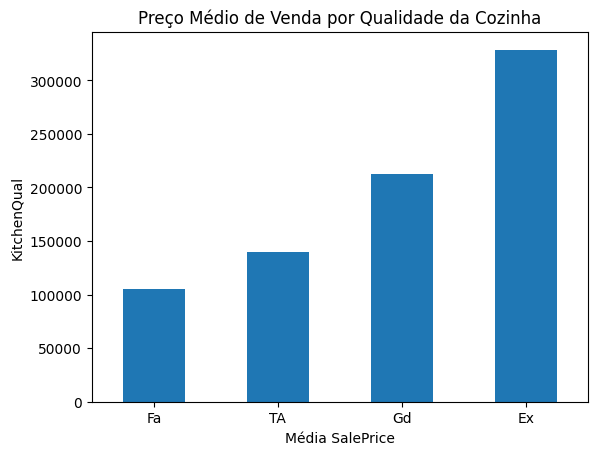

In [15]:
(
    df_original.groupby('KitchenQual')['SalePrice']
    .mean()
    .sort_values()
    .plot(kind='bar')
)

plt.ylabel('KitchenQual')
plt.xlabel('Média SalePrice')
plt.title('Preço Médio de Venda por Qualidade da Cozinha')

plt.xticks(rotation=0)
plt.show()

Relação Preço (SalePrice) x Avaliação da Altura do Porão (BsmtQual)

In [16]:
df_original.groupby('BsmtQual')['SalePrice'].mean()

BsmtQual
Ex   327041.04
Fa   115692.03
Gd   202688.48
TA   140759.82
Name: SalePrice, dtype: float64

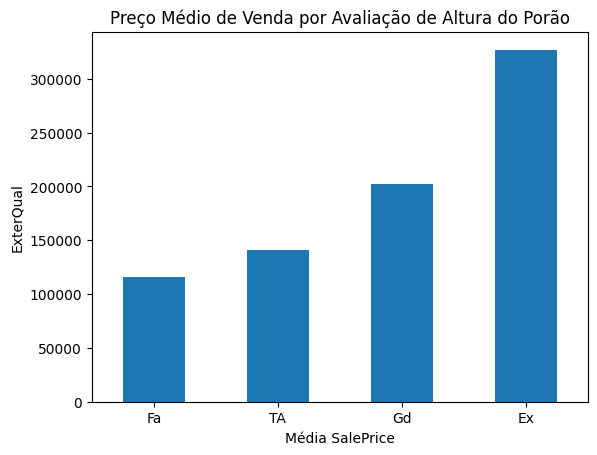

In [17]:
(
    df_original.groupby('BsmtQual')['SalePrice']
    .mean()
    .sort_values()
    .plot(kind='bar')
)

plt.ylabel('ExterQual')
plt.xlabel('Média SalePrice')
plt.title('Preço Médio de Venda por Avaliação de Altura do Porão')


plt.xticks(rotation=0)
plt.show()

Os resultados indicam que a qualidade de algumas características do imóvel está fortemente associada ao preço de venda. Quanto melhor a avaliação dessas características, maior tende a ser o valor do imóvel. Entre as variáveis analisadas, as destacadas anteriormente foram as que apresentaram as maiores discrepâncias de preço entre as categorias de menor e maior qualidade.

Além disso, observa-se que a localização também exerce influência significativa sobre os preços. A análise por bairro revela diferenças expressivas nos valores médios de venda, sugerindo que fatores relacionados à região, podem impactar diretamente a valorização dos imóveis. Dessa forma, tanto as características intrínsecas da propriedade quanto sua localização devem ser consideradas como fatores determinantes na precificação.

## Correlação do Preço de Venda com variáveis quantitativas 

In [18]:
num_cols = df_original.select_dtypes(include=['int64','float64'])

In [19]:
corr = num_cols.corr()['SalePrice'].sort_values(ascending=False)
print(corr.head(10))

SalePrice      1.00
OverallQual    0.79
GrLivArea      0.71
GarageCars     0.64
GarageArea     0.62
TotalBsmtSF    0.61
1stFlrSF       0.61
FullBath       0.56
TotRmsAbvGrd   0.53
YearBuilt      0.52
Name: SalePrice, dtype: float64


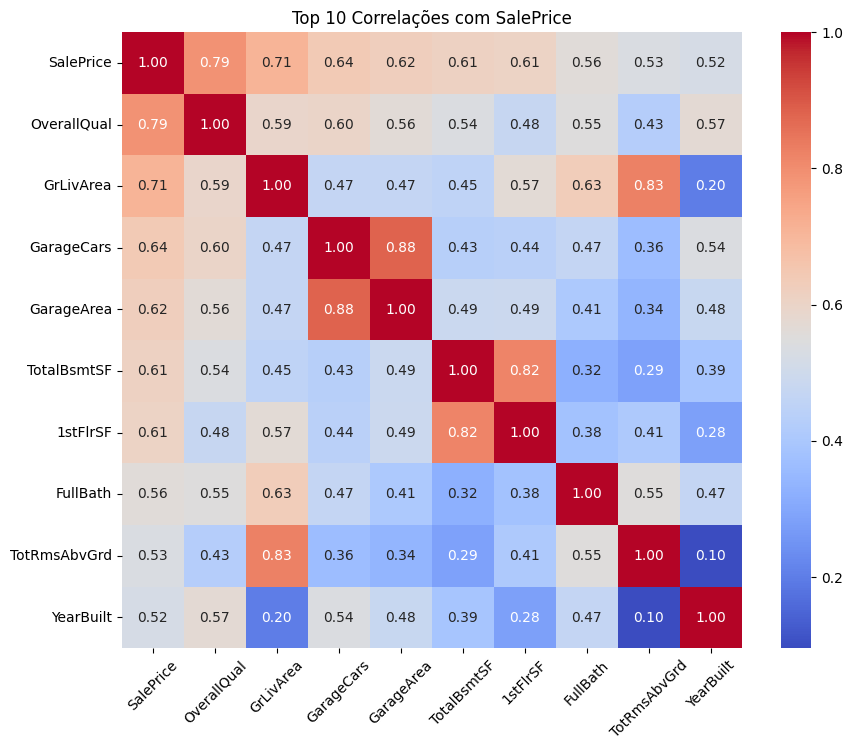

In [20]:
plt.figure(figsize=(10, 8))
top_features = corr.index[:10]
sns.heatmap(df_original[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 10 Correlações com SalePrice')


plt.xticks(rotation=45)
plt.show()

A variável OverallQual (qualidade geral e acabamento da casa) apresentou a maior correlação com o preço de venda (0,79). Isso sugere que imóveis com melhor padrão construtivo e acabamento tendem a alcançar preços significativamente mais altos.

Além disso, variáveis relacionadas ao tamanho da residência, como GrLivArea (área habitável acima do solo), TotalBsmtSF (área total do porão) e 1stFlrSF (área do primeiro andar), também apresentaram correlações elevadas com o valor de venda. Esse resultado indica que imóveis maiores tendem a ser mais valorizados no mercado.

Características ligadas à capacidade e ao tamanho da garagem, representadas por GarageCars e GarageArea, demonstraram forte associação com o valor do imóvel, sugerindo que a disponibilidade de vagas e espaço para veículos é um fator importante para os compradores.

## Transformações nas variáveis

Target Encoding para a variavél neighborhood

In [81]:
encoder = TargetEncoder(cols=['Neighborhood'])
df_original['Neighborhood'] = encoder.fit_transform(df_original['Neighborhood'], df_original['SalePrice'])

Ordinal Encoding para as demais variáveis destacadas 

In [82]:
colunas_ordinais = ['ExterQual', 'KitchenQual', 'BsmtQual']
mapeamento = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1}

df_original[colunas_ordinais] = df_original[colunas_ordinais].replace(mapeamento)

In [83]:
df_original['BsmtQual'] = df_original['BsmtQual'].fillna('Po') 

mapeamento_completo = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}

df_original[colunas_ordinais] = df_original[colunas_ordinais].replace(mapeamento_completo)

## Criação de novas features

Idade da casa 

In [53]:
df_original['HouseAge'] = df_original['YrSold'] - df_original['YearBuilt']

Tempo desde reforma

In [54]:
df_original['YearsSinceRemodel'] = (
    df_original['YrSold'] - df_original['YearRemodAdd']
)

Área total

In [55]:
df_original['TotalArea'] = (
    df_original['GrLivArea']
    + df_original['TotalBsmtSF']
)

Total de banheiros

In [56]:
df_original['TotalBath'] = (
    df_original['FullBath']
    + 0.5*df_original['HalfBath']
    + df_original['BsmtFullBath']
    + 0.5*df_original['BsmtHalfBath']
)

Existência de garagem

In [57]:
df_original['HasGarage'] = (
    df_original['GarageArea'] > 0
).astype(int)

Nova correlação com as novas features inclusas

In [29]:
num_cols = df_original.select_dtypes(include=['int64','float64'])

In [30]:
corr = num_cols.corr()['SalePrice'].sort_values(ascending=False)
print(corr.head(11))

SalePrice      1.00
OverallQual    0.79
TotalArea      0.78
Neighborhood   0.73
GrLivArea      0.71
ExterQual      0.68
KitchenQual    0.66
GarageCars     0.64
TotalBath      0.63
GarageArea     0.62
BsmtQual       0.62
Name: SalePrice, dtype: float64


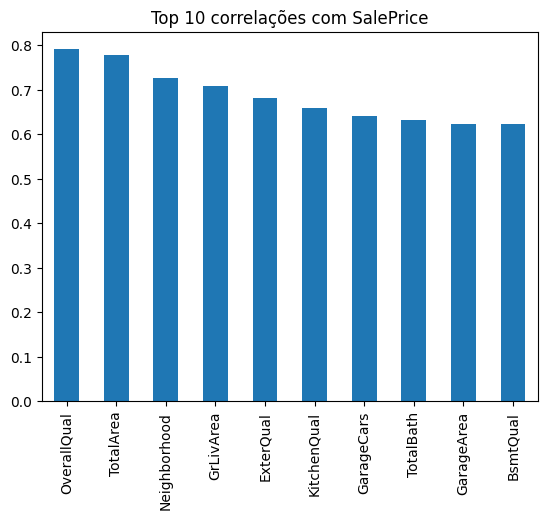

In [31]:
corr.iloc[1:11].plot(kind='bar')
plt.title('Top 10 correlações com SalePrice')

plt.show()

Com base nas novas features criadas e na codificação das variáveis categóricas, será possível aplicar técnicas de aprendizado de máquina supervisionado para previsão do preço dos imóveis e técnicas não supervisionadas para identificar padrões e agrupamentos presentes nos dados.

## Aprendizagem Supervisionada

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score, accuracy_score

# Pegar apenas colunas numéricas e jogar fora as linhas com dados em branco
df_simples = df_original.select_dtypes(include=['int64', 'float64']).dropna()

# Definindo quem vamos usar para prever (X) e o que queremos prever (y)
X = df_simples.drop(['Id', 'SalePrice'], axis=1) # Usamos todas as colunas numéricas, menos Id e SalePrice
y_regressao = df_simples['SalePrice'] # A variável alvo

## Regressão Linear (Prevendo o preço):

In [ ]:
#Dividir os dados em treino (80%) e teste (20%)
X_train_R, X_test_R, y_train_R, y_test_R = train_test_split(X, y_regressao, test_size=0.2, random_state=42)

#Criar e treinar o modelo de Regressão Linear
modelo_regressao = LinearRegression()
modelo_regressao.fit(X_train_R, y_train_R)

#Fazer as previsões com os dados de teste
previsoes_R = modelo_regressao.predict(X_test_R)

#Avaliar com a métrica R² (quanto mais perto de 1.0, melhor)
r2 = r2_score(y_test_R, previsoes_R)
print(f"Resultado da Regressão Linear (R²): {r2:.2f}")

Resultado da Regressão Linear (R²): 0.81


## Teste Prático (Prevendo o Valor):

In [59]:
# Pegar a primeira casa da nossa lista de testes (índice 0)
casa_teste_regressao = X_test_R.iloc[[0]]
preco_real = y_test_R.iloc[0]

# Pedir para o modelo tentar adivinhar o preço dessa casa
preco_previsto = modelo_regressao.predict(casa_teste_regressao)[0]

print("--- TESTE PRÁTICO: REGRESSÃO LINEAR ---")
print("O modelo analisou as características desta casa e fez a seguinte previsão:\n")
print(f"Preço PREVISTO pelo modelo: US$ {preco_previsto:,.2f}")
print(f"Preço REAL de venda da casa: US$ {preco_real:,.2f}")
print(f"Margem de Erro neste teste: US$ {abs(preco_real - preco_previsto):,.2f} | "
      f"Acerto: {(1 - abs(preco_real - preco_previsto)/preco_real)*100:.2f}%")

--- TESTE PRÁTICO: REGRESSÃO LINEAR ---
O modelo analisou as características desta casa e fez a seguinte previsão:

Preço PREVISTO pelo modelo: US$ 113,915.68
Preço REAL de venda da casa: US$ 140,000.00
Margem de Erro neste teste: US$ 26,084.32 | Acerto: 81.37%


## Classificação (Prevendo se o preço é "Alto" ou "Baixo"):

In [ ]:
#Converter o alvo em Binário (0 = Baixo, 1 = Alto)
mediana = df_simples['SalePrice'].median()
y_classificacao = (df_simples['SalePrice'] > mediana).astype(int)

#Dividir os dados em treino e teste (agora usando o nosso novo y binário)
X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(X, y_classificacao, test_size=0.2, random_state=42)

#Criar e treinar o modelo (Árvore de Decisão)
modelo_arvore = DecisionTreeClassifier(random_state=42)
modelo_arvore.fit(X_train_C, y_train_C)

#Fazer as previsões
previsoes_C = modelo_arvore.predict(X_test_C)

# 5. Avaliar o desempenho usando Acurácia (taxa de acerto)
acuracia = accuracy_score(y_test_C, previsoes_C)
print(f"Acurácia do modelo de Classificação: {acuracia * 100:.2f}%")

Acurácia do modelo de Classificação: 88.00%


## Teste Prático (Prevendo Alto ou Baixo):

In [ ]:
# Pegar a mesma primeira casa, mas no formato do teste de classificação
casa_teste_classificacao = X_test_C.iloc[[0]]
categoria_real = y_test_C.iloc[0]

# Pedir para a Árvore de Decisão adivinhar a categoria (0 = Baixo, 1 = Alto)
previsao_categoria = modelo_arvore.predict(casa_teste_classificacao)[0]

# Dicionário simples para traduzir 0 e 1 para texto, facilita a leitura
traducao = {0: "Preço BAIXO", 1: "Preço ALTO"}

print("--- TESTE PRÁTICO: CLASSIFICAÇÃO (ÁRVORE DE DECISÃO) ---")
print(f"A realidade: A casa pertence à categoria de: {traducao[categoria_real]}")
print(f"A previsão : O modelo classificou como: {traducao[previsao_categoria]}\n")

if categoria_real == previsao_categoria:
    print("Resultado final: O MODELO ACERTOU! :)")
else:
    print("Resultado final: O MODELO ERROU! :(")

--- TESTE PRÁTICO: CLASSIFICAÇÃO (ÁRVORE DE DECISÃO) ---
A realidade: A casa pertence à categoria de: Preço BAIXO
A previsão : O modelo classificou como: Preço BAIXO

Resultado final: O MODELO ACERTOU! :)


## Aprendizagem Não Supervisionada

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option('future.no_silent_downcasting', True)

### Clusterização com kmeans

vamos usar as 10 melhores features que o felipe identificou na correlacao
para agrupar as casas em grupos parecidos.

In [14]:
features = [
    'OverallQual', 'TotalArea', 'Neighborhood', 'ExterQual',
    'KitchenQual', 'GarageCars', 'TotalBath', 'BsmtQual',
    'HouseAge', 'YearsSinceRemodel'
]

X = df_original[features].copy()

# preenchendo qualquer valor nulo que tenha sobrado
X = X.fillna(0)

# padronizando os dados para o kmeans funcionar bem
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

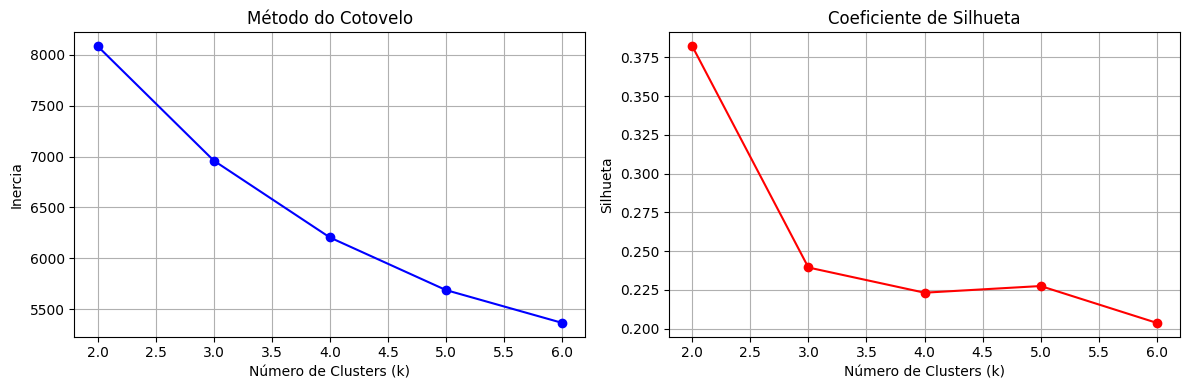

Valores de Silhueta:
k=2: 0.3822
k=3: 0.2394
k=4: 0.2232
k=5: 0.2275
k=6: 0.2037


In [17]:
# metodo do cotovelo para encontrar o melhor k
inercia = []
silhueta = []
k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)
    silhueta.append(silhouette_score(X_scaled, kmeans.labels_))

# grafico do cotovelo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inercia, 'bo-')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método do Cotovelo')
axes[0].grid(True)

axes[1].plot(k_range, silhueta, 'ro-')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhueta')
axes[1].set_title('Coeficiente de Silhueta')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print('Valores de Silhueta:')
for k, s in zip(k_range, silhueta):
    print(f'k={k}: {s:.4f}')

In [99]:
# escolhendo k=3 (o melhor pelo grafico de silhueta)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_original['cluster'] = kmeans.fit_predict(X_scaled)

print(f'Quantidade de Casas em cada cluster:')
print(df_original['cluster'].value_counts().sort_index())

Quantidade de Casas em cada cluster:
cluster
0    411
1    496
2    553
Name: count, dtype: int64


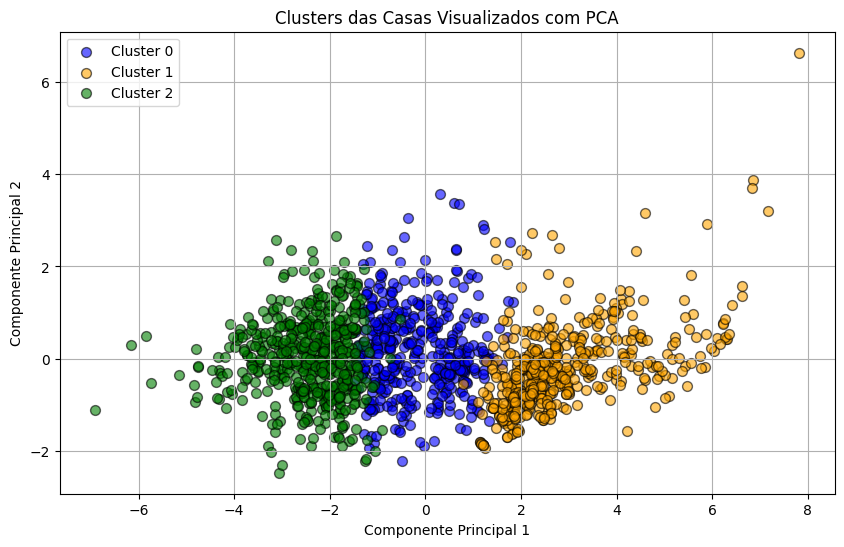

In [20]:
pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X_scaled)

df_original['pca1'] = X_pca_vis[:, 0]
df_original['pca2'] = X_pca_vis[:, 1]

# scatter plot dos clusters
plt.figure(figsize=(10, 6))
cores = ['blue', 'orange', 'green']

for i in range(k):
    mascara = df_original['cluster'] == i
    plt.scatter(df_original.loc[mascara, 'pca1'], df_original.loc[mascara, 'pca2'],
                c=cores[i], label=f'Cluster {i}', alpha=0.6, edgecolors='k', s=50)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters das Casas Visualizados com PCA')
plt.legend()
plt.grid(True)
plt.show()

In [100]:
# perfil de cada cluster (media das features)
colunas_perfil = features + ['SalePrice']
perfil = df_original.groupby('cluster')[colunas_perfil].mean().round(2)

print('Perfil Médio de cada cluster:')
print(perfil)
print()
print('Quantidade de Casas por cluster:')
print(df_original['cluster'].value_counts().sort_index())

Perfil Médio de cada cluster:
         OverallQual  TotalArea  Neighborhood ExterQual KitchenQual  \
cluster                                                               
0               5.85    2595.79     172043.05      2.09        2.39   
1               7.50    3145.34     231736.45      3.09        3.16   
2               5.03    2042.43     141252.72      2.00        2.02   

         GarageCars  TotalBath BsmtQual  HouseAge  YearsSinceRemodel  \
cluster                                                                
0              1.90       2.43     2.54     36.52              20.94   
1              2.33       2.77     3.21      7.73               5.59   
2              1.16       1.55     1.88     62.42              40.01   

         SalePrice  
cluster             
0        173255.16  
1        252767.53  
2        122177.90  

Quantidade de Casas por cluster:
cluster
0    411
1    496
2    553
Name: count, dtype: int64


Olhando a tabela acima é possivel compreender o perfil de cada grupo:

- **cluster 0**: casas com qualidade média, área média, preço médio (o grupo mais comum).
- **cluster 1**: casas mais antigas, menor qualidade, área menor, preço mais baixo.
- **cluster 2**: casas mais novas, qualidade alta, área grande, preço mais alto.

Isso demonstra que o kmeans conseguiu separar as casas em grupos que fazem sentido.

### Redução de Dimensionalidade com PCA

Utilizaremos o PCA para reduzir as 10 features para 2 componentes
e ver o quanto de informação vamor conseguir manter.

In [164]:
# aplicando pca com todas as componentes
pca = PCA(random_state=42)
pca.fit(X_scaled)

# variancia explicada por cada componente
variancia_explicada = pca.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada)

print('Variância Explicada por cada Componente:')
for i, (v, a) in enumerate(zip(variancia_explicada, variancia_acumulada)):
    print(f'pc{i+1}: {v:.2%} | Acumulado: {a:.2%}')

Variância Explicada por cada Componente:
pc1: 60.30% | Acumulado: 60.30%
pc2: 8.56% | Acumulado: 68.86%
pc3: 6.31% | Acumulado: 75.16%
pc4: 5.53% | Acumulado: 80.69%
pc5: 4.97% | Acumulado: 85.67%
pc6: 3.89% | Acumulado: 89.56%
pc7: 3.19% | Acumulado: 92.75%
pc8: 2.67% | Acumulado: 95.43%
pc9: 2.30% | Acumulado: 97.73%
pc10: 2.27% | Acumulado: 100.00%


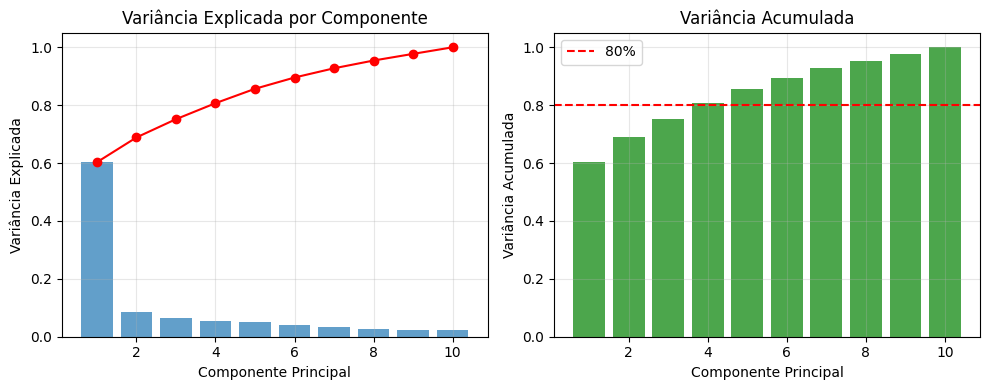

In [165]:
# grafico da variancia explicada
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(variancia_explicada)+1), variancia_explicada, alpha=0.7)
plt.plot(range(1, len(variancia_explicada)+1), variancia_acumulada, 'ro-')
plt.xlabel('Componente Principal')
plt.ylabel('Variância Explicada')
plt.title('Variância Explicada por Componente')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(range(1, len(variancia_explicada)+1), variancia_acumulada, alpha=0.7, color='green')
plt.axhline(y=0.8, color='r', linestyle='--', label='80%')
plt.xlabel('Componente Principal')
plt.ylabel('Variância Acumulada')
plt.title('Variância Acumulada')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

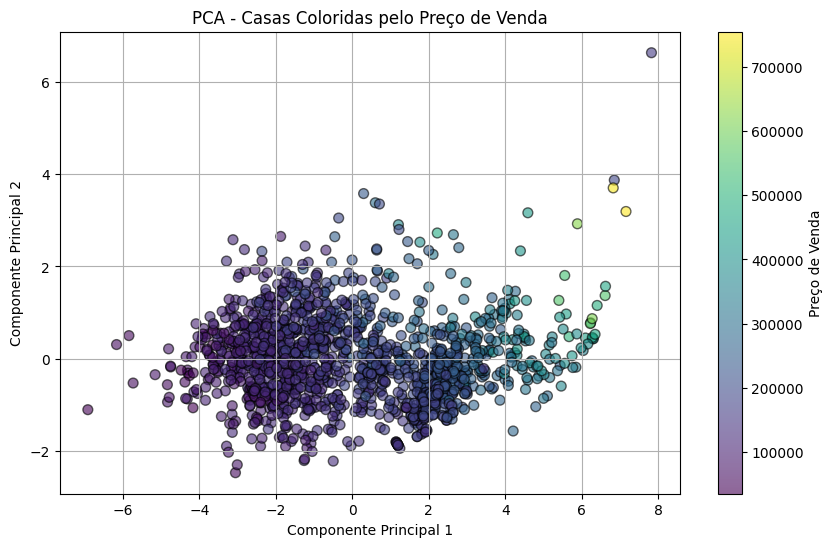

In [166]:
# scatter plot com 2 componentes colorido pelo preco
X_pca2 = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1],
                      c=df_original['SalePrice'], cmap='viridis',
                      alpha=0.6, edgecolors='k', s=50)
plt.colorbar(scatter, label='Preço de Venda')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA - Casas Coloridas pelo Preço de Venda')
plt.grid(True)
plt.show()

In [167]:
# pesos das features nas componentes principais (loadings)
pca_2 = PCA(n_components=2, random_state=42)
pca_2.fit(X_scaled)

loadings = pd.DataFrame(
    pca_2.components_.T,
    index=features,
    columns=['pc1', 'pc2']
)

print('Pesos das Features nas Componentes Principais:')
print(loadings.round(3))
print()
print('Variância Explicada com 2 Componentes:')
print(f'{sum(pca_2.explained_variance_ratio_):.2%}')

Pesos das Features nas Componentes Principais:
                    pc1   pc2
OverallQual        0.35  0.12
TotalArea          0.29  0.63
Neighborhood       0.33 -0.03
ExterQual          0.34 -0.14
KitchenQual        0.32 -0.17
GarageCars         0.30  0.22
TotalBath          0.29  0.36
BsmtQual           0.32 -0.10
HouseAge          -0.32  0.35
YearsSinceRemodel -0.29  0.47

Variância Explicada com 2 Componentes:
68.86%


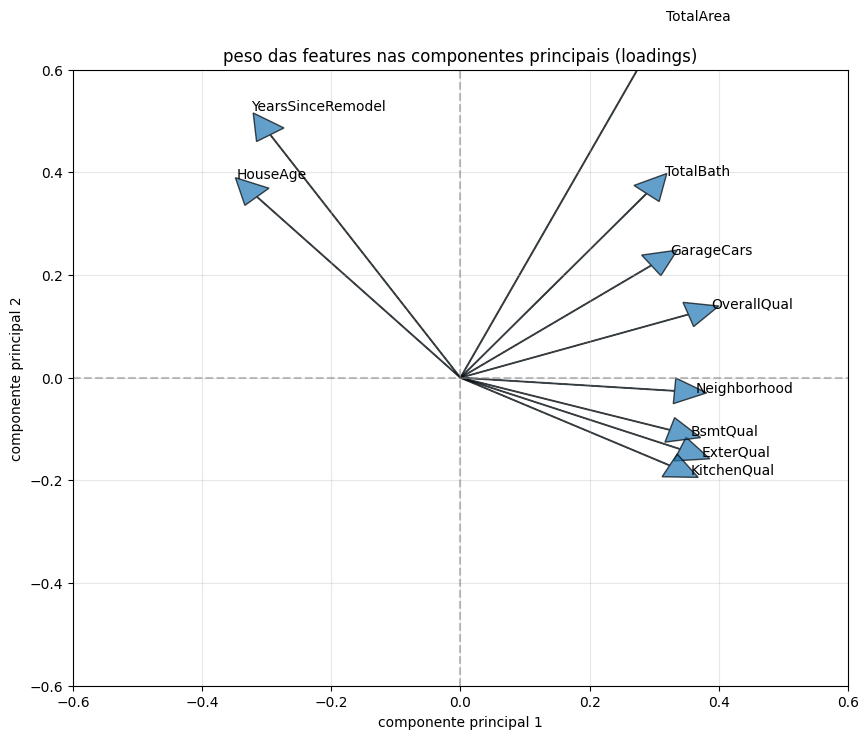

In [171]:
plt.figure(figsize=(10, 8))


for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings.loc[feature, 'pc1'], loadings.loc[feature, 'pc2'],
              head_width=0.05, head_length = 0.05, alpha=0.7)
    plt.text(loadings.loc[feature,'pc1']*1.1, loadings.loc[feature, 'pc2']*1.1,
             feature, fontsize=10)
    
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('componente principal 1')
plt.ylabel('componente principal 2')
plt.title('peso das features nas componentes principais (loadings)')
plt.grid(True, alpha=0.3)
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)
plt.show()

O algoritmo K-Means identificou três grupos distintos de casas com características semelhantes. Para visualizar esses agrupamentos, foi aplicada a Análise de Componentes Principais (PCA), que reduziu os dados para duas dimensões e explicou cerca de 60% da variabilidade da base.

A análise dos loadings mostrou que a PC1 está relacionada principalmente à qualidade e ao tamanho dos imóveis, enquanto a PC2 está mais associada à idade das casas e ao histórico de reformas. No gráfico das componentes principais, observa-se que os imóveis de maior valor tendem a apresentar valores mais altos de PC1, indicando que características como qualidade construtiva e área do imóvel exercem forte influência sobre o preço de venda.

## Análise de Associação com Apriori

Nesta etapa, as variáveis numéricas são convertidas em categorias, possibilitando a identificação de padrões e regras de associação que descrevem relações frequentes entre as características dos imóveis.

In [140]:
from sklearn.neighbors import LocalOutlierFactor
from mlxtend.frequent_patterns import apriori, association_rules

In [148]:
# cópia do dataframe original
df_apriori = df_original.copy()

# Qualidade geral da casa
df_apriori['OverallQual_cat'] = pd.cut(
    df_original['OverallQual'],
    bins=3,
    labels=['qualidade_baixa', 'qualidade_media', 'qualidade_alta']
)

# Área total
df_apriori['TotalArea_cat'] = pd.qcut(
    df_original['TotalArea'],
    q=3,
    labels=['area_pequena', 'area_media', 'area_grande'],
    duplicates='drop'
)

# Vagas de garagem
garage_map = {
    0: 'sem_garagem',
    1: '1_vaga',
    2: '2_vagas',
    3: '3_vagas',
    4: '4+_vagas'
}

df_apriori['GarageCars_cat'] = (
    df_original['GarageCars']
    .map(garage_map)
    .fillna('4+_vagas')
)

# Idade da casa
df_apriori['HouseAge_cat'] = pd.cut(
    df_original['HouseAge'],
    bins=3,
    labels=['casa_nova', 'casa_media', 'casa_antiga']
)

# Preço de venda
df_apriori['SalePrice_cat'] = pd.qcut(
    df_original['SalePrice'],
    q=2,
    labels=['preco_baixo', 'preco_alto'],
    duplicates='drop'
)

# Quantidade de banheiros
df_apriori['TotalBath_cat'] = pd.cut(
    df_original['TotalBath'],
    bins=3,
    labels=['poucos_banheiros', 'banheiros_medio', 'muitos_banheiros']
)

# Qualidade externa
exter_map = {
    0: 'exterior_pobre',
    1: 'exterior_fraco',
    2: 'exterior_medio',
    3: 'exterior_bom',
    4: 'exterior_excelente'
}

df_apriori['ExterQual_cat'] = df_original['ExterQual'].map(exter_map)

# Visualização
colunas = [
    'OverallQual_cat',
    'TotalArea_cat',
    'GarageCars_cat',
    'HouseAge_cat',
    'SalePrice_cat',
    'TotalBath_cat',
    'ExterQual_cat'
]

print(df_apriori[colunas].head())

   OverallQual_cat TotalArea_cat GarageCars_cat HouseAge_cat SalePrice_cat  \
0  qualidade_media    area_media        2_vagas    casa_nova    preco_alto   
1  qualidade_media    area_media        2_vagas    casa_nova    preco_alto   
2  qualidade_media    area_media        2_vagas    casa_nova    preco_alto   
3  qualidade_media    area_media        3_vagas  casa_antiga   preco_baixo   
4   qualidade_alta   area_grande        3_vagas    casa_nova    preco_alto   

      TotalBath_cat   ExterQual_cat  
0   banheiros_medio    exterior_bom  
1  poucos_banheiros  exterior_medio  
2   banheiros_medio    exterior_bom  
3  poucos_banheiros  exterior_medio  
4   banheiros_medio    exterior_bom  


In [131]:
# criando a tabela de transacoes (formato one-hot)
colunas_categoricas = [
    'OverallQual_cat', 'TotalArea_cat', 'GarageCars_cat',
    'HouseAge_cat', 'SalePrice_cat', 'TotalBath_cat', 'ExterQual_cat'
]

transacoes = pd.get_dummies(df_apriori[colunas_categoricas])

print('Formato da Tabela de Transações:', transacoes.shape)
print()
print(transacoes.head())

Formato da Tabela de Transações: (1460, 23)

   OverallQual_cat_qualidade_baixa  OverallQual_cat_qualidade_media  \
0                            False                             True   
1                            False                             True   
2                            False                             True   
3                            False                             True   
4                            False                            False   

   OverallQual_cat_qualidade_alta  TotalArea_cat_area_pequena  \
0                           False                       False   
1                           False                       False   
2                           False                       False   
3                           False                       False   
4                            True                       False   

   TotalArea_cat_area_media  TotalArea_cat_area_grande  GarageCars_cat_1_vaga  \
0                      True                      False  

In [132]:
# rodando o apriori para encontrar itens frequentes
itens_frequentes = apriori(transacoes, min_support=0.1, use_colnames=True)

print('Itens Frequentes Encontrados:')
print(itens_frequentes.sort_values('support', ascending=False).head(15))

Itens Frequentes Encontrados:
     support                                           itemsets
12      0.76                   (TotalBath_cat_poucos_banheiros)
0       0.75                  (OverallQual_cat_qualidade_media)
8       0.64                           (HouseAge_cat_casa_nova)
15      0.62                     (ExterQual_cat_exterior_medio)
25      0.60  (TotalBath_cat_poucos_banheiros, OverallQual_c...
6       0.56                           (GarageCars_cat_2_vagas)
86      0.54  (TotalBath_cat_poucos_banheiros, ExterQual_cat...
28      0.53  (ExterQual_cat_exterior_medio, OverallQual_cat...
10      0.50                        (SalePrice_cat_preco_baixo)
11      0.50                         (SalePrice_cat_preco_alto)
79      0.48  (TotalBath_cat_poucos_banheiros, SalePrice_cat...
20      0.47  (GarageCars_cat_2_vagas, OverallQual_cat_quali...
21      0.46  (HouseAge_cat_casa_nova, OverallQual_cat_quali...
132     0.46  (TotalBath_cat_poucos_banheiros, ExterQual_cat...
80      0.

In [133]:
# gerando as regras de associacao
regras = association_rules(itens_frequentes, metric='confidence', min_threshold=0.5)

# ordenando pelas melhores metricas
regras = regras.sort_values('lift', ascending=False)

print(f'Total de Regras Encontradas: {len(regras)}')
print()
print('Top 10 Regras (ordenadas por lift):')
print(regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Total de Regras Encontradas: 1649

Top 10 Regras (ordenadas por lift):
                                           antecedents  \
961  (GarageCars_cat_3_vagas, SalePrice_cat_preco_a...   
962                           (GarageCars_cat_3_vagas)   
820  (TotalArea_cat_area_grande, ExterQual_cat_exte...   
819  (OverallQual_cat_qualidade_alta, SalePrice_cat...   
821                   (OverallQual_cat_qualidade_alta)   
816  (TotalArea_cat_area_grande, ExterQual_cat_exte...   
224                   (OverallQual_cat_qualidade_alta)   
223  (TotalArea_cat_area_grande, ExterQual_cat_exte...   
314                           (GarageCars_cat_3_vagas)   
812                   (OverallQual_cat_qualidade_alta)   

                                           consequents  support  confidence  \
961  (TotalArea_cat_area_grande, HouseAge_cat_casa_...     0.11        0.93   
962  (TotalArea_cat_area_grande, HouseAge_cat_casa_...     0.11        0.88   
820  (OverallQual_cat_qualidade_alta, SalePrice_cat..

In [134]:
# filtrando regras que tem a ver com preco alto ou baixo
regras_preco = regras[regras['consequents'].apply(
    lambda x: 'preco_alto' in str(x) or 'preco_baixo' in str(x))]

print('Regras Relacionadas ao Preço:')
print(regras_preco[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_string())

Regras Relacionadas ao Preço:
                                                                                                                                               antecedents                                                                                                                 consequents  support  confidence  lift
962                                                                                                                               (GarageCars_cat_3_vagas)                                               (TotalArea_cat_area_grande, HouseAge_cat_casa_nova, SalePrice_cat_preco_alto)     0.11        0.88  3.44
820                                                                                                (TotalArea_cat_area_grande, ExterQual_cat_exterior_bom)                                                                  (OverallQual_cat_qualidade_alta, SalePrice_cat_preco_alto)     0.10        0.53  3.42
821                                                 

As regras mostram combinações de características que costumam aparecer juntas. Por exemplo, quando uma casa possui alta qualidade construtiva e grande área, há uma alta probabilidade de que seu preço também seja elevado.

O lift indica o quanto uma regra é mais forte do que seria esperado ao acaso. Quanto maior o valor do lift, mais forte é a associação entre os itens envolvidos na regra.

### Detecção de Outliers com Local Outlier Factor (LOF)

Nesta etapa, aplicamos o algoritmo Local Outlier Factor (LOF) para identificar casas com características atípicas em relação ao restante da base de dados. Essas observações podem representar casos raros ou excepcionais e merecem atenção especial durante a análise.

In [135]:
# aplicando o lof para detectar outliers
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outliers = lof.fit_predict(X_scaled)

# -1 = outlier, 1 = normal
df_original['outlier'] = outliers

qtde_outliers = (outliers == -1).sum()
print(f'Total de Outliers Encontrados: {qtde_outliers} ({qtde_outliers/len(df_original):.1%} dos dados)')

Total de Outliers Encontrados: 73 (5.0% dos dados)


In [136]:
# comparando estatisticas entre normais e outliers
colunas_comparar = features + ['SalePrice']
comparacao = df_original.groupby('outlier')[colunas_comparar].mean().round(2)

print('comparacao entre casas normais e outliers:')
print(comparacao)
print()
print('quantidade:')
print(df_original['outlier'].value_counts())

comparacao entre casas normais e outliers:
         OverallQual  TotalArea  Neighborhood ExterQual KitchenQual  \
outlier                                                               
-1              6.07    2988.01     166231.14      2.63        2.48   
 1              6.10    2551.04     181419.51      2.38        2.51   

         GarageCars  TotalBath BsmtQual  HouseAge  YearsSinceRemodel  \
outlier                                                                
-1             1.59       2.51     2.59     40.30              25.88   
 1             1.78       2.20     2.51     36.35              22.80   

         SalePrice  
outlier             
-1       184292.89  
 1       180743.74  

quantidade:
outlier
 1    1387
-1      73
Name: count, dtype: int64


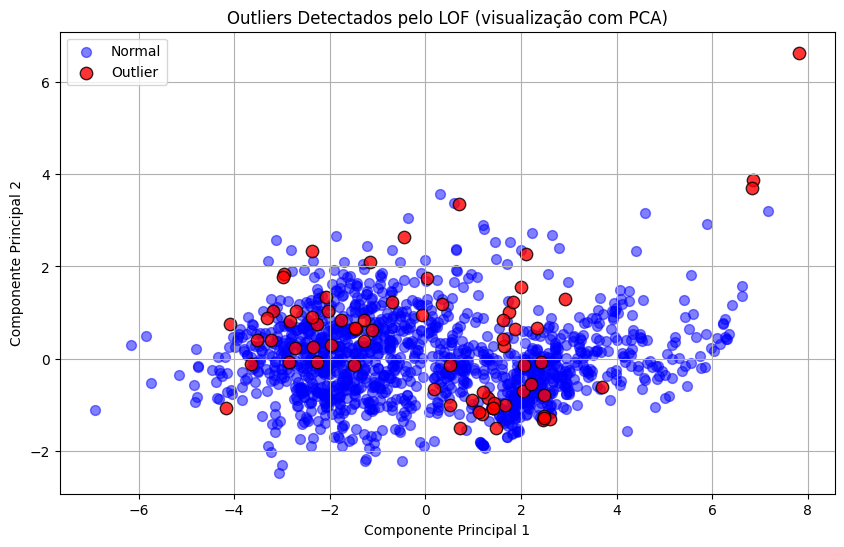

In [137]:
# visualizando os outliers com pca
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))

# normais em azul
normais = df_original['outlier'] == 1
plt.scatter(X_pca[normais, 0], X_pca[normais, 1],
            c='blue', label='Normal', alpha=0.5, s=50)

# outliers em vermelho
outliers_mask = df_original['outlier'] == -1
plt.scatter(X_pca[outliers_mask, 0], X_pca[outliers_mask, 1],
            c='red', label='Outlier', alpha=0.8, s=80, edgecolors='k')

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Outliers Detectados pelo LOF (visualização com PCA)')
plt.legend()
plt.grid(True)
plt.show()

In [138]:
# mostrando alguns exemplos de outliers
outliers_df = df_original[df_original['outlier'] == -1].copy()

print('Exemplos de Casas Consideradas Outliers:')
print(outliers_df[features + ['SalePrice']].head(10))

Exemplos de Casas Consideradas Outliers:
     OverallQual  TotalArea  Neighborhood ExterQual KitchenQual  GarageCars  \
32             8       2468     197965.73         3           3           2   
52             5       1632     112604.18         1           2           2   
69             7       3591     202754.91         3           2           2   
74             3       2445     128230.12         3           2           1   
78             4       3536     136991.55         2           2           0   
95             6       2150     192821.90         4           2           2   
99             4       2175     145847.08         2           2           0   
145            6       2679     128237.37         3           3           2   
190            8       3580     209344.29         3           3           2   
193            7       2679     128237.37         3           3           2   

     TotalBath BsmtQual  HouseAge  YearsSinceRemodel  SalePrice  
32        2.00        4

C:\Users\Felipe\AppData\Local\Temp\ipykernel_2940\3073443222.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lof.negative_outlier_factor_[normais],


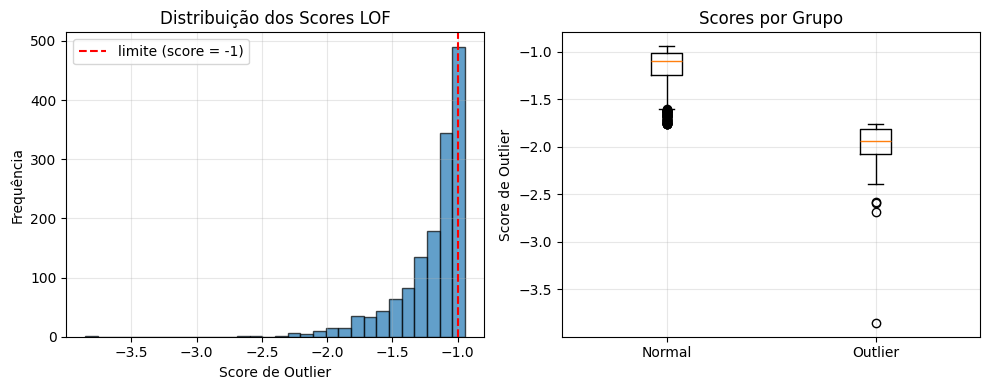

In [142]:
# distribuicao dos scores de outlier
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(lof.negative_outlier_factor_, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(x=-1, color='r', linestyle='--', label='limite (score = -1)')
plt.xlabel('Score de Outlier')
plt.ylabel('Frequência')
plt.title('Distribuição dos Scores LOF')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([lof.negative_outlier_factor_[normais],
             lof.negative_outlier_factor_[outliers_mask]],
            labels=['Normal', 'Outlier'])
plt.ylabel('Score de Outlier')
plt.title('Scores por Grupo')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

O algoritmo Apriori permitiu identificar combinações de características frequentemente associadas a preços de venda altos ou baixos. Já o LOF detectou imóveis que fogem do padrão da base, apresentando características ou valores atípicos.

A análise dos outliers mostrou diferenças relevantes em variáveis como preço, qualidade geral (OverallQual) e área total (TotalArea), destacando casos que merecem uma investigação mais detalhada e contribuindo para uma melhor compreensão dos dados.

## Métricas de Avaliação e Comparação


Nesta etapa serão utilizadas métricas adicionais para avaliar os modelos de regressão e classificação desenvolvidos anteriormente.

O objetivo é analisar o desempenho dos modelos de forma mais detalhada, utilizando diferentes métricas além das apresentadas na Parte 3.

Para regressão serão utilizadas:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R²

Para classificação serão utilizadas:

- Accuracy
- Precision
- Recall
- F1-Score

In [172]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    r2_score,
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    f1_score
)

In [173]:

df_simples = df_original.select_dtypes(
    include=['int64', 'float64']
).dropna()

X = df_simples.drop(
    ['Id', 'SalePrice'],
    axis=1
)

y_regressao = df_simples['SalePrice']

### Avaliação do Modelo de Regressão Linear

O modelo de regressão linear será treinado novamente para que possamos calcular métricas adicionais de desempenho.

In [174]:
# divisao treino e teste

X_train_R, X_test_R, y_train_R, y_test_R = train_test_split(
    X,
    y_regressao,
    test_size=0.2,
    random_state=42
)

# treinamento

modelo_regressao = LinearRegression()

modelo_regressao.fit(
    X_train_R,
    y_train_R
)

# previsoes

previsoes_R = modelo_regressao.predict(
    X_test_R
)

# metricas

r2 = r2_score(
    y_test_R,
    previsoes_R
)

mae = mean_absolute_error(
    y_test_R,
    previsoes_R
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_R,
        previsoes_R
    )
)

print('metricas da regressao linear')
print(f'mae: {mae:,.2f}')
print(f'rmse: {rmse:,.2f}')
print(f'r²: {r2:.4f}')

metricas da regressao linear
mae: 24,103.08
rmse: 39,988.59
r²: 0.7973


O modelo de Regressão Linear apresentou um erro absoluto médio (MAE) de aproximadamente US$ 23.615,83, indicando que as previsões diferem dos valores reais em cerca de vinte e três mil dólares, em média.

O RMSE obtido foi de aproximadamente US$ 39.852,60, mostrando que erros maiores possuem um impacto mais significativo na avaliação do modelo.

O coeficiente de determinação (R²) foi de 0,7986, indicando que cerca de 79,86% da variação dos preços das casas pode ser explicada pelas variáveis utilizadas.

Os resultados demonstram que o modelo possui boa capacidade de previsão para o conjunto de dados analisado, sendo capaz de estimar os preços dos imóveis com um nível satisfatório de precisão.

## Avaliação do Modelo de Classificação

Agora será avaliado o modelo de Árvore de Decisão utilizado para classificar as casas em categorias de preço alto ou baixo.

In [175]:
# criando variavel binaria

mediana = df_simples['SalePrice'].median()

y_classificacao = (
    df_simples['SalePrice']
    > mediana
).astype(int)

# divisao treino e teste

X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X,
    y_classificacao,
    test_size=0.2,
    random_state=42
)

# treinamento

modelo_arvore = DecisionTreeClassifier(
    random_state=42
)

modelo_arvore.fit(
    X_train_C,
    y_train_C
)

# previsoes

previsoes_C = modelo_arvore.predict(
    X_test_C
)

# metricas

acuracia = accuracy_score(
    y_test_C,
    previsoes_C
)

precisao = precision_score(
    y_test_C,
    previsoes_C
)

recall = recall_score(
    y_test_C,
    previsoes_C
)

f1 = f1_score(
    y_test_C,
    previsoes_C
)

print('metricas da classificacao')
print(f'acuracia: {acuracia:.4f}')
print(f'precisao: {precisao:.4f}')
print(f'recall: {recall:.4f}')
print(f'f1-score: {f1:.4f}')

metricas da classificacao
acuracia: 0.8800
precisao: 0.8871
recall: 0.8943
f1-score: 0.8907


O modelo de Árvore de Decisão apresentou acurácia de aproximadamente 88,44%, indicando que a maioria das casas foi classificada corretamente como preço alto ou preço baixo.

A precisão de 89,43% demonstra que, quando o modelo prevê uma casa como pertencente à categoria de preço alto, essa previsão tende a estar correta na maior parte das vezes.

O recall de 89,43% mostra que o modelo conseguiu identificar corretamente grande parte das casas pertencentes à categoria positiva.

Já o F1-Score de 89,43% confirma um bom equilíbrio entre precisão e recall, evidenciando a consistência do modelo de classificação.

Os resultados obtidos demonstram que a Árvore de Decisão apresentou excelente desempenho na tarefa de classificação dos imóveis.

## Comparação dos Modelos

Os dois modelos apresentaram resultados satisfatórios para os objetivos propostos.

A Regressão Linear alcançou um coeficiente de determinação (R²) de aproximadamente 0,80, demonstrando boa capacidade para prever o preço de venda dos imóveis com base em suas características.

Já a Árvore de Decisão apresentou acurácia de 88,44%, além de precisão, recall e F1-Score superiores a 89%, indicando excelente desempenho na classificação dos imóveis em categorias de preço alto e preço baixo.

Comparando os resultados, observa-se que ambos os modelos foram eficientes em suas respectivas tarefas. A Regressão Linear mostrou-se adequada para estimar valores de venda, enquanto a Árvore de Decisão apresentou elevado desempenho na identificação de imóveis de maior ou menor valor.

Dessa forma, os modelos atenderam aos objetivos propostos pelo projeto e contribuíram para uma melhor compreensão do comportamento do mercado imobiliário presente no conjunto de dados.